<a href="https://colab.research.google.com/github/LeruaValero/projects_openbio/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%965_%D0%9B%D0%BE%D0%B3%D0%B8%D0%BD%D0%BE%D0%B2%D0%B0_%D0%92%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашняя работа №5

*Цели практикума*  
В ходе практикума построили модель для предсказания выживаемости пациента с раком груди на основе данных экспрессии, метилирования и микроРНК. Для обучения модели будем использовать данные по раку груди из TCGA.  

Данные TCGA уже отобранные в удобном виде для построения моделей на основе мультиомиксных данных можно скачать из статьи - https://www.nature.com/articles/s41467-020-20430-7

Для построения регрессии нам нужно получить набор признаков. Для их построения использовали алгоритмы предназначенные для мультиомиксной интеграции данных. В качестве таких алгоритмов взяты MOFA, PCA и автоэнкодер. С использованием этих подходов получены наборы эмбеддингов, которые дальше станут основой для построения региресионной модели. В качестве предсказываемого параметра использовались значения survival - день после установки диагноза для которого есть информация о том жив индивид или нет.

В ходе выполнения домашнего задания предлагается расширить содержание практикума, а именно добавить дополнительные методы интеграции мультиомиксных данных или же изменить параметры у существующих.



Программа минимум



- Запустить MOFA c параметром convergence_mode=«fast» и ответить на вопрос: «Сильно ли поменялось качество регресионной модели? ». Подсказка нужно добавить параметр при вызове функции train_mofa.



- Попробовать эмпирически подобрать оптимальное количество эпох для обучения автоэнкодера. Оптимальное количество в смысле получения максимально возможного качества регресионной модели(параметры MAPE и C-index



Дополнение:



- Добавить в качестве метода интеграции мультиомиксных данных UMAP. Оценить качество регрессионной модели.



Как добавить UMAP указано ниже:



os.system("pip install umap-learn")

import umap

reducer = umap.UMAP(n_components=N_FACTORS, random_state=RANDOM_STATE)

umap_factors = reducer.fit_transform(X_breast_all)

umap_metrics = regression_pipeline(umap_factors, *pipeline_args)

m_f_umap, m_c_umap, c_f_umap, c_c_umap = umap_metrics.values()



- Попробовать изменить архитектуру автоэнкодера, например на приведённую ниже:



class Autoencoder(nn.Module):

    def __init__(self, input_dims, n_out):

        super(Autoencoder, self).__init__()

        dna_encoder = nn.Sequential(

            nn.Linear(input_dims[0], 128),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.3)

        )

        rna_encoder = nn.Sequential(

            nn.Linear(input_dims[1], 128),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.3)

        )

        met_encoder = nn.Sequential(

            nn.Linear(input_dims[2], 128),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.3)

        )

        self.encoder = nn.ModuleList([dna_encoder, rna_encoder, met_encoder])

        self.bottleneck = nn.Linear(128 * len(input_dims), n_out)

        self.decoder = nn.ModuleList([nn.Sequential(

            nn.Linear(n_out, dim),

            nn.Sigmoid()

        ) for dim in input_dims])

    def forward(self, inputs):

        encoded = [encoder(input)

                   for encoder, input in zip(self.encoder, inputs)]

        merged = torch.cat(encoded, dim=1)

        bottleneck = self.bottleneck(merged)

        decoded = [decoder(bottleneck) for decoder in self.decoder]

        return decoded

    def encode(self, inputs):

        encoded = [encoder(input)

                   for encoder, input in zip(self.encoder, inputs)]

        merged = torch.cat(encoded, dim=1)

        bottleneck = self.bottleneck(merged)

        return bottleneck

class EncoderPipeline():

………………………………………………………………

    def fit(self):

………………………………………………………………

                targets = inputs

………………………………………………………………

Оцените качество полученной на его основе регрессионной модели.



(*)Опишите архитектуру Автоэнкодера, код которого приведён в тексте задания.

## Подготовка среды

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive/')

In [ ]:
import os,sys

In [ ]:
os.system("pip install mofapy2")
os.system("pip install datasets")
os.system("pip install catboost")
os.system("pip install scikit-survival")

0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from mofapy2.run.entry_point import entry_point
import h5py
import time
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from sklearn.decomposition import PCA
import torch
import random
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader

from datasets import Dataset
from torch.utils.data.dataloader import default_collate

import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import roc_auc_score, roc_curve, mean_absolute_percentage_error, classification_report, mean_squared_error
from sksurv.metrics import concordance_index_censored
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer

RANDOM_STATE = 42

In [ ]:
os.environ['WANDB_DISABLED'] = 'true'

## Подготовка данных

In [ ]:
os.system("wget https://acgt.cs.tau.ac.il/multi_omic_benchmark/data/breast.zip")

0

Данные загружаем по ссылке - https://acgt.cs.tau.ac.il/multi_omic_benchmark/data/breast.zip  
Разархивируем:

In [ ]:
os.system("unzip breast.zip")

0

У нас 4 текстовых файла:  
exp - транскриптомные данные

methy - данные метилирования

mirna - данные микрорнк

survivavl - данные по выживаемости

Что делаем в ходе предобработки: отбираем только тех пациентов, для которых есть данные по выживаемости (так как хотим понять насколько разные наши подходы к предсказанию выживаемтости насколько хорошо они работают и какой из них лучше) ; убираем признаки у которых все значения - нули, признаки с нулевой дисперсией (у которых одно и то же значение, они не информативны) и самые высокодисперсные (могут исказить результаты); применяем стандартизацию. Сохраняем каждую модальность отдельно.

Подготовим данные по выживаемости:

In [ ]:
#удаляем дубликаты
def handle_duplicates(df):
    inconsistent_patient_ids = []

    for patient_id, group in df.groupby('PatientID'):
        if group['Death'].nunique() > 1:
            inconsistent_patient_ids.append(patient_id)

    if inconsistent_patient_ids:
        print("Inconsistent Patient IDs:", inconsistent_patient_ids)
        df = df[~df['PatientID'].isin(inconsistent_patient_ids)]
    else:
        df = df.drop_duplicates(subset='PatientID')

    return df

#подготовка данных по выживаемости
def prepare_survival_data(path, id_sep='.'):
    survival_data = pd.read_csv(path, sep='\t')
    survival_data['PatientID'] = survival_data['PatientID'].str.lower()

    if id_sep == '-':
        survival_data['PatientID'] = survival_data['PatientID'].apply(lambda x: "-".join(x.split("-")[:-1]))
        survival_data['PatientID'] = survival_data['PatientID'].str.replace('-', '.')

    survival_data = handle_duplicates(survival_data) #удаляем дубликаты
    survival_data = survival_data.dropna(subset=['Death']) #удаляем индивидов без данных о выживаемости, а именно есть нет данных в столбце Death
    #то мы не можем знать жив ли пациент на дату указанную в солбце survival или нет и мы не сможем использовать эту информацию дальше.

    survival_data = survival_data.set_index('PatientID')
    survival_data = survival_data.sort_index()
    return survival_data

In [ ]:
survival_data_breast = prepare_survival_data('survival')
survival_data_breast

,Survival,Death
PatientID,,
tcga.3c.aaau,4047.0,0.0
tcga.3c.aali,4005.0,0.0
tcga.3c.aalj,1474.0,0.0
tcga.3c.aalk,1448.0,0.0
tcga.4h.aaak,348.0,0.0
...,...,...
tcga.wt.ab44,883.0,0.0
tcga.xx.a899,467.0,0.0
tcga.xx.a89a,488.0,0.0


Первый столбец - ID пациента, второй столбец - количество дней, третий - состояние пациента (0 жив, 1 летальный). Целевой признак это столбец "Survival".

In [ ]:
survival_data_breast.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1095 entries, tcga.3c.aaau to tcga.z7.a8r6
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survival  1095 non-null   float64
 1   Death     1095 non-null   float64
dtypes: float64(2)
memory usage: 25.7+ KB


In [ ]:
survival_data_breast.isna().sum()

,0
Survival,0
Death,0


In [ ]:
survival_data_breast.duplicated().sum()

224

Вообще видим что есть явные дубликаты, далее их удаляем в процессе подготовки данных

In [ ]:
survival_data_breast[survival_data_breast.duplicated()].sort_values("PatientID")

,Survival,Death
PatientID,,
tcga.a2.a0cw,3283.0,0.0
tcga.a2.a0ye,554.0,0.0
tcga.a2.a0yl,1474.0,0.0
tcga.a2.a1g1,584.0,0.0
tcga.a2.a4s3,666.0,0.0
...,...,...
tcga.s3.aa12,574.0,0.0
tcga.s3.aa17,424.0,0.0
tcga.ul.aaz6,518.0,0.0


Попозже подумаю нужно ли их удалять, по сути да

Загрузим экспрессионные данные.  
В столбцах пациенты. Для каждого пациента тут есть ожно значение экспрессии. В строках уровни экспрессии.

In [ ]:
pd.read_csv('exp', sep=' ')

,TCGA.3C.AAAU.01,TCGA.3C.AALI.01,TCGA.3C.AALJ.01,TCGA.3C.AALK.01,TCGA.4H.AAAK.01,TCGA.5L.AAT0.01,TCGA.5L.AAT1.01,TCGA.5T.A9QA.01,TCGA.A1.A0SB.01,TCGA.A1.A0SD.01,...,TCGA.UL.AAZ6.01,TCGA.UU.A93S.01,TCGA.V7.A7HQ.01,TCGA.W8.A86G.01,TCGA.WT.AB41.01,TCGA.WT.AB44.01,TCGA.XX.A899.01,TCGA.XX.A89A.01,TCGA.Z7.A8R5.01,TCGA.Z7.A8R6.01
?|100130426,0.0000,0.0000,0.9066,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
?|100133144,16.3644,9.2659,11.6228,12.0894,6.8468,3.9889,0.0000,1.4644,15.3396,9.5178,...,0.3992,4.3126,0.0000,5.5624,0.0000,0.0000,14.3858,22.3240,2.2638,6.8865
?|100134869,12.9316,17.3790,9.2294,11.0799,14.4298,13.6090,10.5949,8.9958,14.3935,11.3241,...,14.3720,10.8828,3.0792,14.3711,6.3091,3.2580,21.4409,27.2744,7.2933,24.7795
?|10357,52.1503,69.7553,154.2974,143.8643,84.2128,114.2572,115.9984,107.5628,116.3870,60.2630,...,135.6241,136.1288,29.9974,128.3151,53.6278,42.2643,137.7756,64.1427,85.0461,167.5511
?|10431,408.0760,563.8934,1360.8341,865.5358,766.3830,807.7431,1108.3945,1420.5021,657.2812,977.9175,...,1570.1445,2886.3965,1721.8816,697.6744,1245.2681,1877.4180,652.7559,722.7208,1140.2801,1003.5668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYX|7791,3507.2482,5504.6221,5458.7489,5691.3529,4041.7021,4131.9842,4418.0929,3221.7573,6186.7327,3559.6725,...,4163.4978,5594.0666,6453.3611,5550.5458,6675.8675,10937.0800,5118.1102,5477.5626,6675.6264,3402.5228
ZZEF1|23140,1894.9342,1318.6514,942.8830,781.1336,831.9149,922.1293,1411.5729,1115.0628,1931.2986,1278.9678,...,1242.3823,538.3502,747.6267,970.0997,558.3596,800.6516,1933.8583,1437.4114,754.4127,564.4193
ZZZ3|26009,1180.4565,406.7428,509.5195,700.8688,881.7021,1061.7393,568.8672,440.8996,1436.1978,1195.6000,...,310.5956,386.3965,303.6079,870.9065,287.0662,443.0869,670.0787,953.7081,750.8288,462.1140
psiTPTE22|387590,1.7233,926.5905,35.3581,66.6115,187.2340,85.0565,57.8647,3.6611,552.3144,86.0144,...,10.7790,7.2359,286.9803,220.2183,28.3912,724.9033,98.4252,235.2385,238.9272,20.8786


Загрузим данные метилирования.  
Тоже самое - в столбцах пациенты, в строках индентификаторы ГЦ-остравов, в строках уровни метелирования у каждого пациента.

In [ ]:
pd.read_csv('methy', sep=' ')

,TCGA.3C.AAAU.01,TCGA.3C.AALI.01,TCGA.3C.AALJ.01,TCGA.3C.AALK.01,TCGA.4H.AAAK.01,TCGA.5L.AAT0.01,TCGA.5L.AAT1.01,TCGA.5T.A9QA.01,TCGA.A1.A0SB.01,TCGA.A1.A0SE.01,...,TCGA.UL.AAZ6.01,TCGA.UU.A93S.01,TCGA.V7.A7HQ.01,TCGA.W8.A86G.01,TCGA.WT.AB41.01,TCGA.WT.AB44.01,TCGA.XX.A899.01,TCGA.XX.A89A.01,TCGA.Z7.A8R5.01,TCGA.Z7.A8R6.01
cg00001583,0.242943,0.020153,0.462715,0.541054,0.515059,0.341272,0.494101,0.685513,0.034492,0.471522,...,0.505995,0.207384,0.160676,0.316727,0.592305,0.672427,0.294309,0.367615,0.304950,0.099811
cg00001747,0.031749,0.057154,0.057074,0.545638,0.616939,0.379243,0.530568,0.841713,0.014405,0.055475,...,0.792027,0.387466,0.173250,0.037222,0.545911,0.695487,0.517730,0.369683,0.077868,0.335720
cg00002719,0.516227,0.783211,0.697199,0.674409,0.617353,0.542329,0.482340,0.931028,0.018781,0.658939,...,0.933619,0.832528,0.730904,0.597186,0.538606,0.441444,0.372236,0.451676,0.377488,0.860880
cg00011616,0.941399,0.935964,0.948888,0.184844,0.114255,0.213250,0.319228,0.960389,0.022631,0.208805,...,0.952293,0.147546,0.169631,0.135495,0.276987,0.132223,0.394446,0.797703,0.271380,0.044378
cg00013655,0.050625,0.623837,0.625223,0.766111,0.050625,0.650243,0.590676,0.866059,0.343111,0.814525,...,0.897715,0.811783,0.816055,0.050625,0.517769,0.050625,0.534657,0.050625,0.600615,0.940253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rs9363764,0.210427,0.098401,0.066748,0.088968,0.506823,0.484411,0.568019,0.042672,0.542891,0.728922,...,0.622314,0.060533,0.060903,0.552864,0.084895,0.536523,0.926969,0.489924,0.868085,0.546954
rs939290,0.578899,0.549295,0.939740,0.039935,0.935489,0.951828,0.935498,0.673841,0.025628,0.517138,...,0.052870,0.821048,0.556301,0.949188,0.938692,0.563087,0.954865,0.446231,0.058715,0.025949
rs951295,0.945994,0.961865,0.714945,0.527980,0.524704,0.514265,0.950553,0.960879,0.962202,0.545724,...,0.238549,0.553625,0.524953,0.395858,0.955757,0.051110,0.514547,0.035183,0.956065,0.543114
rs966367,0.418134,0.845781,0.767472,0.813171,0.066034,0.430883,0.073960,0.344072,0.954142,0.478139,...,0.435256,0.575495,0.947476,0.473874,0.739639,0.054815,0.503835,0.330966,0.067769,0.505955


Загрузим данные микроРНК.  


In [ ]:
pd.read_csv('mirna',sep=' ')

,TCGA.3C.AAAU.01,TCGA.3C.AALI.01,TCGA.3C.AALJ.01,TCGA.3C.AALK.01,TCGA.4H.AAAK.01,TCGA.5L.AAT0.01,TCGA.5L.AAT1.01,TCGA.5T.A9QA.01,TCGA.A1.A0SB.01,TCGA.A1.A0SD.01,...,TCGA.UL.AAZ6.01,TCGA.UU.A93S.01,TCGA.V7.A7HQ.01,TCGA.W8.A86G.01,TCGA.WT.AB41.01,TCGA.WT.AB44.01,TCGA.XX.A899.01,TCGA.XX.A89A.01,TCGA.Z7.A8R5.01,TCGA.Z7.A8R6.01
hsa-let-7a-1,8962.996542,7739.739862,8260.612670,9056.241254,10897.303665,10200.138892,11153.663212,13567.338022,12429.699816,12405.901338,...,2677.325815,7277.083612,8599.915211,13460.719906,8394.086822,10628.975280,16799.785282,13120.807001,7979.531224,10439.110392
hsa-let-7a-2,17779.575039,15524.941906,16497.981335,18075.168478,21822.338727,20324.284843,22358.808693,26885.686105,24983.587912,24953.282453,...,5384.579691,14488.117766,17202.014092,26784.845790,16805.146283,21125.108661,33603.904432,26337.935723,16006.280243,20880.967721
hsa-let-7a-3,9075.200383,7713.626636,8355.342958,9097.666150,10963.956320,10277.088579,11165.853267,13652.627394,12530.053982,12470.431701,...,2762.716886,7251.150732,8545.635421,13471.067938,8497.485928,10585.686678,16883.338223,13229.425112,8106.687917,10649.126224
hsa-let-7b,24749.898857,23374.640471,10957.355911,26017.522731,22204.253575,24432.140695,25025.945288,35090.798790,93052.564676,51022.818423,...,2696.820240,11597.818928,12458.459583,37885.064640,15376.764680,23396.813364,20731.006597,18796.895124,20462.010937,17770.685685
hsa-let-7c,341.298400,801.487258,635.811272,2919.348415,3313.009950,2254.229465,2494.345531,587.121030,10750.858237,2739.740038,...,165.290754,1818.477039,1625.898073,5671.641311,2424.630873,3892.051211,5263.331356,6581.549565,4040.296936,1330.766196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-95,4.124452,1.258469,1.644623,1.739213,0.810860,1.640135,1.301850,6.327921,2.090712,2.435108,...,0.823708,1.058485,4.367339,1.149781,3.126539,1.217492,2.318115,0.931545,1.656765,2.746937
hsa-mir-96,119.984057,60.249189,97.252043,72.572624,19.947145,92.257618,27.812260,51.173623,47.668229,21.672461,...,85.116501,26.144577,47.416828,66.457360,55.161078,79.813361,16.629958,41.919511,55.225491,44.949881
hsa-mir-98,53.992826,86.047798,117.645369,41.583007,34.380445,40.730030,62.607173,40.168543,63.975781,50.893758,...,87.587625,44.562214,68.629619,34.953352,63.200749,57.627952,57.348159,54.215901,53.016472,80.160621
hsa-mir-99a,130.201449,236.434808,191.434123,1046.690127,1081.037952,658.787729,633.409436,122.431517,4130.410239,1134.760339,...,42.832820,668.962450,599.573311,1647.866592,869.177798,1100.883277,1919.601107,1310.124456,1120.939408,470.225698


Подготовим омиксные датасеты:

In [ ]:
#Подготовка омиксных датасетов
def prepare_data(path, patient_ids=None):
    data = pd.read_csv(path, sep=' ')

    data = data.T #транспонируем
    data.index = data.index.str.lower() #имена образцов записываем в нижнем регистре
    data.index = data.index.str.replace(r'\.01$', '', regex=True) #удаляем .01 в конце названий

    if patient_ids is not None:
        data = data[data.index.isin(patient_ids)] #оставим только тех индивидов которые в спике заданном параметром patient_ids
    data = data.sort_index() #отсортируем образцы
    return data

#Специфическая подготовка для mofa
def preprocess_data_for_mofa(df):
    # удаление признаков у которых все значения 0
    columns_all_zeros = ~df.all(axis=0)
    df = df.loc[:, ~columns_all_zeros]

    # удаляем признаки для которых дисперсия равна нулю
    variances = df.var()
    df = df.loc[:, variances != 0]

    # удаление признаков с наибольшей дисперсией
    threshold = variances.quantile(0.95)
    columns_to_keep = variances[variances <= threshold].index
    df = df[columns_to_keep]

    # нормализация
    standard_scaler = StandardScaler()
    df = pd.DataFrame(standard_scaler.fit_transform(
        df), columns=df.columns, index=df.index)

    return df

#выбираем только общих индивидов
def choose_common_patients(dfs):
    df1, df2, df3, df4 = dfs
    common_indexes = set(df1.index) & set(
      df2.index) & set(df3.index) & set(df4.index)

    df1_sync = df1[df1.index.isin(common_indexes)]
    df2_sync = df2[df2.index.isin(common_indexes)]
    df3_sync = df3[df3.index.isin(common_indexes)]
    df4_sync = df4[df4.index.isin(common_indexes)]

    return df1_sync, df2_sync, df3_sync, df4_sync


Перемеиновываем данные, делаем стандартизацию, удаляем нулевые признаки и с наибольшей/наименьшей дисперссией.

In [ ]:
# подготавливаем экспресионные данные
expression_data_breast = prepare_data('exp', survival_data_breast.index)
expression_data_breast = preprocess_data_for_mofa(expression_data_breast)

#подготавливаем данные метилирования
methylation_data_breast = prepare_data('methy', survival_data_breast.index)
methylation_data_breast = preprocess_data_for_mofa(methylation_data_breast)

#подготавливаем данные микроРНК
mirna_data_breast = prepare_data('mirna', survival_data_breast.index)
mirna_data_breast = preprocess_data_for_mofa(mirna_data_breast)

#оставляем только тех индивидов которые имеют все данные
survival_data_breast, expression_data_breast, methylation_data_breast, mirna_data_breast = choose_common_patients(
    [survival_data_breast, expression_data_breast, methylation_data_breast, mirna_data_breast])

#удаляем признаки с пропущенными значениями
expression_data_breast = expression_data_breast.dropna(axis=1, how='any')
methylation_data_breast = methylation_data_breast.dropna(axis=1, how='any')
mirna_data_breast = mirna_data_breast.dropna(axis=1, how='any')

#сохраняем в виде csv файлой
survival_data_breast.to_csv('survival_data_breast.csv')
expression_data_breast.to_csv('expression_data_breast.csv')
methylation_data_breast.to_csv('methylation_data_breast.csv')
mirna_data_breast.to_csv('mirna_data_breast.csv')

In [ ]:
survival_data_breast.info()
survival_data_breast.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 620 entries, tcga.3c.aaau to tcga.z7.a8r6
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survival  620 non-null    float64
 1   Death     620 non-null    float64
dtypes: float64(2)
memory usage: 14.5+ KB


,0
Survival,0
Death,0


In [ ]:
expression_data_breast.info()
expression_data_breast.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 620 entries, tcga.3c.aaau to tcga.z7.a8r6
Columns: 12127 entries, ?|10357 to psiTPTE22|387590
dtypes: float64(12127)
memory usage: 57.4+ MB


,0
?|10357,0
?|10431,0
?|155060,0
?|57714,0
?|653553,0
...,...
ZYG11B|79699,0
ZYX|7791,0
ZZEF1|23140,0
ZZZ3|26009,0


In [ ]:
methylation_data_breast.info()
methylation_data_breast.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 620 entries, tcga.3c.aaau to tcga.z7.a8r6
Columns: 4750 entries, cg00001583 to rs654498
dtypes: float64(4750)
memory usage: 22.5+ MB


,0
cg00001583,0
cg00001747,0
cg00002719,0
cg00011616,0
cg00025347,0
...,...
cg27664085,0
rs10033147,0
rs2208123,0
rs2959823,0


In [ ]:
mirna_data_breast.info()
mirna_data_breast.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 620 entries, tcga.3c.aaau to tcga.z7.a8r6
Columns: 182 entries, hsa-let-7a-1 to hsa-mir-99a
dtypes: float64(182)
memory usage: 886.4+ KB


,0
hsa-let-7a-1,0
hsa-let-7a-2,0
hsa-let-7a-3,0
hsa-let-7b,0
hsa-let-7c,0
...,...
hsa-mir-92a-2,0
hsa-mir-92b,0
hsa-mir-93,0
hsa-mir-98,0


Трансформируем данные в общий датафрейм в формате MOFA

In [ ]:
#преобразуем df в melted_df
def transform_df_for_mofa(df, view):
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'sample'}, inplace=True)
    melted_df = df.melt(
        id_vars='sample', var_name='feature', value_name='value')
    melted_df['view'] = view
    return melted_df

transformed_expression_data_breast = transform_df_for_mofa(
    expression_data_breast.copy(), 'expression')
transformed_methylation_breast = transform_df_for_mofa(
    methylation_data_breast.copy(), 'methylation')
transformed_mirna_data_breast = transform_df_for_mofa(
    mirna_data_breast.copy(), 'mirna')
combined_data_breast = pd.concat([transformed_expression_data_breast,
                                  transformed_methylation_breast, transformed_mirna_data_breast], axis=0)

combined_data_breast.to_csv('mofa_data_breast.csv')
combined_data_breast #ниже показано как выглядит melted df. Он необходим для MOFA

,sample,feature,value,view
0,tcga.3c.aaau,?|10357,-1.042741,expression
1,tcga.3c.aali,?|10357,-0.756164,expression
2,tcga.3c.aalj,?|10357,0.620028,expression
3,tcga.3c.aalk,?|10357,0.450196,expression
4,tcga.4h.aaak,?|10357,-0.520822,expression
...,...,...,...,...
112835,tcga.wt.ab44,hsa-mir-99a,0.353295,mirna
112836,tcga.xx.a899,hsa-mir-99a,1.334040,mirna
112837,tcga.xx.a89a,hsa-mir-99a,0.603946,mirna
112838,tcga.z7.a8r5,hsa-mir-99a,0.377321,mirna


Идея такая, что мы храним в "melted df" наши данные след образом: для каждой тройки образец-признак и модальность хранится значение для каждой тройки в виде строки, т.е. для всех возможных кобинаций образец-признак-модальность мы делаем строки и т.о. преобразуем датасет.

Загружаем клинические данные, нужны для регрессии, провери м насколько эта модельность хорошо работает.

In [ ]:
os.system("wget https://acgt.cs.tau.ac.il/multi_omic_benchmark/data/clinical.zip")
os.system("unzip clinical.zip")

0

## Интеграция мультиомиксных данных и получение факторов

Загружаем предобработанные данные

In [ ]:
survival_data_breast = pd.read_csv('survival_data_breast.csv') # загружаем данные о выживаемости
expression_data_breast = pd.read_csv('expression_data_breast.csv', index_col=[0]) # загружаем транскриптомные данные

mirna_data_breast = pd.read_csv('mirna_data_breast.csv', index_col=[0]) # загружаем данные по микроРНК

methylation_data_breast = pd.read_csv('methylation_data_breast.csv', index_col=[0]) # загружаем данные по метилированию

clinical_data_breast = pd.read_csv('clinical/breast',sep='\t') # загружаем клинические данные

mofa_data_breast = pd.read_csv('mofa_data_breast.csv') # загружаем melted df для MOFA

X_breast_all = np.hstack([expression_data_breast.values, mirna_data_breast.values, methylation_data_breast.values])

"X_breast_all" - большой объединенный датасет для PCA.

Разделяем на трейн и тест данные. Размер тестового датасета 25%, а обучающего 75%.

In [ ]:
def split_patients_for_target_prediction(target_df, test_size=0.25, random_state=RANDOM_STATE, stratify_by='Death'):
    stratify = None
    if stratify_by:
        stratify = target_df[stratify_by]
    indices_train, indices_test = train_test_split(
        target_df.index, test_size=test_size, random_state=random_state, stratify=stratify)

    return indices_train, indices_test

N_FACTORS = 20
TRAIN_INDICES, TEST_INDICES = split_patients_for_target_prediction(survival_data_breast)


Предобработка клинических данных:

Из клинических данных вручную отобираем признаки, которые не связаны с выживаемостью, содержат более 80% непустых данных и более 1 уникального значения, и которые не являются техническими (названия файлов, идентификаторы и прочее) - это делаем чтобя взять только специфический набор клинических данных, в которых нет данных о выживаемости, чтобы не было data leakage (выход не протек во вход).

In [ ]:
CATEGORICAL_CLINICAL_FEATURES = [
                                 'anatomic_neoplasm_subdivision',
                                 'axillary_lymph_node_stage_method_type',
                                 'breast_carcinoma_estrogen_receptor_status',
                                 'breast_carcinoma_progesterone_receptor_status',
                                 'breast_carcinoma_surgical_procedure_name',
                                 'gender',
                                 'histological_type',
                                 'history_of_neoadjuvant_treatment',
                                 'icd_10',
                                 'icd_o_3_histology',
                                 'icd_o_3_site',
                                 'initial_pathologic_diagnosis_method',
                                 'lab_proc_her2_neu_immunohistochemistry_receptor_status',
                                 'margin_status',
                                 'menopause_status',
                                 'new_tumor_event_after_initial_treatment',
                                 'oct_embedded',
                                 'pathologic_M',
                                 'pathologic_N',
                                 'pathologic_T',
                                 'pathologic_stage',
                                 'person_neoplasm_cancer_status',
                                 'primary_lymph_node_presentation_assessment',
                                 'radiation_therapy',
                                 'system_version',
                                 'tissue_prospective_collection_indicator',
                                 'tissue_retrospective_collection_indicator',
                                 'tissue_source_site']
NUMERICAL_CLINICAL_FEATURES = ['age_at_initial_pathologic_diagnosis',
                               'initial_weight', 'lymph_node_examined_count', 'number_of_lymphnodes_positive_by_he']
N_CATEGORICAL_CLINICAL = len(CATEGORICAL_CLINICAL_FEATURES)
N_NUMERIC_CLINICAL = len(NUMERICAL_CLINICAL_FEATURES)

In [ ]:
clinical_features = clinical_data_breast[NUMERICAL_CLINICAL_FEATURES + CATEGORICAL_CLINICAL_FEATURES]

for col in CATEGORICAL_CLINICAL_FEATURES:
    clinical_features[col] = clinical_features[col].fillna('missing')

clinical_features.head()

,age_at_initial_pathologic_diagnosis,initial_weight,lymph_node_examined_count,number_of_lymphnodes_positive_by_he,anatomic_neoplasm_subdivision,axillary_lymph_node_stage_method_type,breast_carcinoma_estrogen_receptor_status,breast_carcinoma_progesterone_receptor_status,breast_carcinoma_surgical_procedure_name,gender,...,pathologic_N,pathologic_T,pathologic_stage,person_neoplasm_cancer_status,primary_lymph_node_presentation_assessment,radiation_therapy,system_version,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,tissue_source_site
0,55.0,60.0,13.0,4.0,Left Lower Outer Quadrant,Sentinel lymph node biopsy plus axillary disse...,Positive,Positive,Modified Radical Mastectomy,FEMALE,...,NX,TX,Stage X,WITH TUMOR,YES,NO,6th,NO,YES,3C
1,50.0,120.0,15.0,1.0,Right Upper Outer Quadrant,Sentinel lymph node biopsy plus axillary disse...,Positive,Positive,Lumpectomy,FEMALE,...,N1a,T2,Stage IIB,TUMOR FREE,YES,YES,6th,NO,YES,3C
2,62.0,NaN,23.0,1.0,Right,missing,Positive,Positive,Modified Radical Mastectomy,FEMALE,...,N1a,T2,Stage IIB,TUMOR FREE,YES,NO,7th,NO,YES,3C
3,52.0,140.0,2.0,0.0,Right,Sentinel node biopsy alone,Positive,Positive,Simple Mastectomy,FEMALE,...,N0 (i+),T1c,Stage IA,TUMOR FREE,YES,NO,7th,NO,YES,3C
4,50.0,770.0,14.0,4.0,Left|Left Upper Outer Quadrant,Axillary lymph node dissection alone,Positive,Positive,Modified Radical Mastectomy,FEMALE,...,N2a,T2,Stage IIIA,TUMOR FREE,YES,NO,7th,YES,NO,4H


In [ ]:
clinical_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1247 entries, 0 to 1246
Data columns (total 32 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   age_at_initial_pathologic_diagnosis                     1242 non-null   float64
 1   initial_weight                                          1051 non-null   float64
 2   lymph_node_examined_count                               1110 non-null   float64
 3   number_of_lymphnodes_positive_by_he                     1068 non-null   float64
 4   anatomic_neoplasm_subdivision                           1247 non-null   object 
 5   axillary_lymph_node_stage_method_type                   1247 non-null   object 
 6   breast_carcinoma_estrogen_receptor_status               1247 non-null   object 
 7   breast_carcinoma_progesterone_receptor_status           1247 non-null   object 
 8   breast_carcinoma_surgical_procedure_na

In [ ]:
clinical_features.isna().sum()

,0
age_at_initial_pathologic_diagnosis,5
initial_weight,196
lymph_node_examined_count,137
number_of_lymphnodes_positive_by_he,179
anatomic_neoplasm_subdivision,0
axillary_lymph_node_stage_method_type,0
breast_carcinoma_estrogen_receptor_status,0
breast_carcinoma_progesterone_receptor_status,0
breast_carcinoma_surgical_procedure_name,0
gender,0


Есть столбцы с явными пропусками

## MOFA

In [ ]:
#функция для запуска интеграции мультиомиксных данных с использованием MOFA
def train_mofa(data_df, random_state=42, factors=10, train_params={'iter': 5000, 'convergence_mode': 'slow'}):
    ent = entry_point()
    # Устанавливаем опции для подготовки данных
    # - scale_views: приводить ли разные модальности в одинаковый диапазон по дисперсии. Мы не будем этого делать поэтому false
    ent.set_data_options(
        scale_views=False
    )

    # В качестве входных данных используем data frame
    ent.set_data_df(data_df)

    # устанавливаем параметры модели(параметр factors по умолчанию:10; ard_Factors - использовать оценки параметра sparsity общую для групп)
    ent.set_model_options(
        factors=factors,
        ard_factors=True
    )

    ## установливаем параметры обучения ##
    # - iter: число итераций
    # - convergence_mode: "fast", "medium", "slow". Чем медленее тем точнее происходит оптимизация. - режим конвергенции,
    # - dropR2: минимальное значени объясняемой дисперсии для того чтобы оставить фактор во время обучения. По умолчанию None.
    # - gpu_mode: Использовать GPU или нет
    # - seed: random seed

    ent.set_train_options(
        **train_params,
        gpu_mode=False,
        seed=random_state,
        quiet=True
    )

    ####################################
    ## Строим и обучаем MOFA модель ##
    ####################################

    # Строим модель
    ent.build()

    # Запускем обучение модели
    ent.run()

    ####################
    ## Сохраняем модель ##
    ####################

    outfile = f"data/outputs/test_{time.time()}.hdf5"

    # - save_data: сохранять ли данные обучения в hdf5 файле.
    ent.save(outfile, save_data=True)

    #########################
    ## Downstream analysis ##
    #########################

    #

    # Извлекаем значение факторов
    factors = ent.model.nodes["Z"].getExpectation()

    # Извлекаем веса
    weights = ent.model.nodes["W"].getExpectation()

    # Извлекаем значения объясняемой дисперсии
    r2 = ent.model.calculate_variance_explained()

    return factors, weights, r2

"convergence_mode" - режим конвергенции, сначала запустим MOFA c параметром convergence_mode = «slow», затем попробуем с «fast» (в конце тетрадки).  
Но мы заранее можем сделать вывод, что чем медленнее тем точнее получается модель.

In [ ]:
#запускаем MOFA
RANDOM_STATE = 42
N_FACTORS = 20 # число факторов
mofa_factors, weights, r2 = train_mofa(mofa_data_breast.copy(), RANDOM_STATE, factors=N_FACTORS)
clear_output()

## PCA

In [ ]:
N_FACTORS = 20 # число PCA факторов. Давайте называть PCA компоненты факторами
pca = PCA(n_components=N_FACTORS) # строим PCA
pca_factors = pca.fit_transform(X_breast_all) #получаем факторы для PCA

## Автоэнкодер

In [ ]:
#Задаём автоэнкодер
class Autoencoder(nn.Module):
    def __init__(self, input_dims, n_out):
        super(Autoencoder, self).__init__()
        hidden_dim = sum([d for d in input_dims])
        # кодирующий слой, на входе общее число признаков в трёх модальностях на выходе 128 признаков
        self.encoder = nn.Sequential(
            nn.Linear(hidden_dim, 128), # на входе энкодера hidden_dim(общее число признаков во всех модальностях) признаков, на выходе 128
            nn.Tanh(), # функция активации tanh
            nn.Dropout(0.5) # применяем dropout с вероятностью 0.5
        )
        # скрытый слой из 128 узлов
        self.bottleneck = nn.Linear(128, n_out) # на входе 128 признаков, на выходе столько сколько факторов задано

        # декодирующий слой
        self.decoder = nn.Sequential(
            nn.Linear(n_out, hidden_dim), # на входе количество признаков равное числу факторов на выходе общее число признаков во всех модальностях
            nn.Sigmoid() # функция активации
        )

    def forward(self, inputs): # прямой проход через сеть
        inputs = torch.cat(inputs, dim=1) # объединяем данные в одну матрицу
        encoded = self.encoder(inputs) # прогоняем через кодирующий слой
        bottleneck = self.bottleneck(encoded) # прогоняем через скрытый слой
        # bottleneck - содержит искомые факторы
        decoded = self.decoder(bottleneck) # прогоняем через декодер
        return decoded # на выходе реконструированные признаки после декодирующего слоя

    def encode(self, inputs): # прогоняем данные через кодирующий слой и скрытый внутренний слой
        inputs = torch.cat(inputs, dim=1) # объединяем данные в одну матрицу
        encoded = self.encoder(inputs) # прогоняем через кодирующий слой
        bottleneck = self.bottleneck(encoded) # прогоняем через скрытый слой
        return bottleneck # на выходе признаки, полученные после кодирования и сжатия в скрытом слое. Это и есть факторы.




class EncoderPipeline(): # Основной класс создающий и обучающий автоэнкодер
    def __init__(self, modalities, n_out, random_state, base=False):
        self.modalities = modalities
        self.random_state = random_state
        self.input_dims = [mod.shape[1] for mod in self.modalities]
        self.model = Autoencoder(self.input_dims, n_out) # создаём автоэнкодер self.input_dims входных признаков n_out - число признаков после внутреннего скрытого слоя автоэнкодера перед декодером
        # это и есть наши эмбеддинги
        self.device = torch.device("cpu") # всё это делаем на CPU
        self.train_loader = self.create_loader(self.modalities) # преобразуем данные в формат pytorch Tensor

    def create_loader(self, modalities):
        dna_train, rna_train, methylation_train = [
            torch.tensor(mod, dtype=torch.float32) for mod in modalities
        ]
        train_dataset = TensorDataset(dna_train, rna_train, methylation_train)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
        self.train_dataset = Dataset.from_dict({
            "inputs": train_dataset.tensors,
        })
        return train_loader

    def fit(self): # обучаем модель
        random.seed(self.random_state)
        np.random.seed(self.random_state)
        torch.manual_seed(self.random_state)
        torch.cuda.manual_seed_all(self.random_state)

        self.model.to(self.device)

         # Создаём оптимизатор и функцию потерь
        optimizer = optim.AdamW(self.model.parameters(), lr=0.001)
        criterion = nn.MSELoss()

        # Обучение
        for epoch in range(50): # используем 50 эпох
            self.model.train() #инициализация
            running_loss = 0.0
            for data in self.train_loader:
                inputs = [modality.to(self.device) for modality in data]
                targets = torch.cat(inputs, dim=1)

                optimizer.zero_grad()
                outputs = self.model(inputs)
                # значение функции потерь
                loss = sum(criterion(output, target)
                           for output, target in zip(outputs, targets))
                # считаем градиент
                loss.backward()
                # обновляем веса
                optimizer.step()

                running_loss += loss.item()

            print(f"Epoch {epoch+1}, Loss: {running_loss}")

    def transform(self, modalities=None): # подсчёт факторов для данных
        self.model.to(self.device)
        self.model.eval()
        output = []
        with torch.no_grad():
            to_transform = self.train_loader if not modalities else self.create_loader(modalities)
            for data in to_transform:
                inputs = [modality.to(self.device) for modality in data]
                outputs = self.model.encode(inputs)
                output.append(outputs.cpu())
        output = np.vstack(output)
        return output

In [ ]:
torch.set_num_threads(1)

# создаём автоэнкодер
enc_pipeline = EncoderPipeline([expression_data_breast.values, mirna_data_breast.values, methylation_data_breast.values], N_FACTORS, RANDOM_STATE, base=False)
# обучаем автоэнкодер
enc_pipeline.fit()

clear_output()
#считаем эмбеддинги
autoenc_factors = enc_pipeline.transform()

## Предсказание выживаемости

Регрессионную модель строим с использованием CatBoost. В качестве предсказываемого параметра используем survival - число дней для которых известно состояние индивида(0 - жив, 1-умер). В качестве признаков используем эмбеддинги полученные с использованием MOFA, PCA и автоэнкодером. Так же делаем два разных регрессора с использованием клинических данных и без использования клинических данных. Для каждого регрессора показываем значимость каждого из используемых признаков в виде графика.  
Для первых 10 признаков:

In [ ]:
pipeline_args = [clinical_features, survival_data_breast, TRAIN_INDICES, TEST_INDICES, RANDOM_STATE,
                       N_FACTORS, N_NUMERIC_CLINICAL, NUMERICAL_CLINICAL_FEATURES + CATEGORICAL_CLINICAL_FEATURES]

In [ ]:
def regression_pipeline(
        factors, clinical_features, survival_data_breast, TRAIN_INDICES, TEST_INDICES,
        RANDOM_STATE, N_FACTORS, N_NUMERIC_CLINICAL, CLINICAL_FEATURES, plot_feat_imp=True):
    # Создаём dataframe клинические данные + факторы
    combined_df = pd.concat([pd.DataFrame(factors), clinical_features], axis=1)
    cat_features_indices = list(
        range(N_FACTORS + N_NUMERIC_CLINICAL, combined_df.shape[1]))

    # Датафрейм только с факторами
    factors_df = pd.DataFrame(factors)

    # Разделяем данные на трейн и тест для dataframe с клиническими данными + факторами
    X_train, X_test, y_train, y_test = combined_df.values[TRAIN_INDICES], combined_df.values[TEST_INDICES], survival_data_breast[
        'Survival'][TRAIN_INDICES], survival_data_breast['Survival'][TEST_INDICES]

    # Разделяем данные на трейн и тест для dataframe только с факторами
    X_train_factors, X_test_factors = factors_df.values[
        TRAIN_INDICES], factors_df.values[TEST_INDICES]

    # Создание модели регрессии для dataframe клинические данные + факторы
    cb_regressor_combined = CatBoostRegressor(
        n_estimators=1000, random_state=RANDOM_STATE, silent=True, cat_features=cat_features_indices)
    cb_regressor_combined.fit(X_train, y_train)

    # Создание модели регрессии для dataframe только с факторами
    cb_regressor_factors = CatBoostRegressor(
        n_estimators=1000, random_state=RANDOM_STATE, silent=True)
    cb_regressor_factors.fit(X_train_factors, y_train)

    # Предсказание и оценка для dataframe факторы + клинические данные
    y_pred_combined = cb_regressor_combined.predict(X_test)
    # Предсказание и оценка для dataframe только с факторами
    y_pred_factors = cb_regressor_factors.predict(X_test_factors)

    event = survival_data_breast['Death'][TEST_INDICES].astype(bool)
    # Метрики для dataframe только с факторами
    mape_factors = mean_absolute_percentage_error(
        y_true=y_test, y_pred=y_pred_factors) * 100
    c_index_factors = concordance_index_censored(
        event, y_test, 1 / y_pred_factors)[0]

    # Метрики для dataframe факторы + клинические данные
    mape_combined = mean_absolute_percentage_error(
        y_true=y_test, y_pred=y_pred_combined) * 100
    c_index_combined = concordance_index_censored(
        event, y_test, 1 / y_pred_combined)[0]

    metrics = {
        'MAPE_f': mape_factors,
        'MAPE_f_c': mape_combined,
        'C-index_f': c_index_factors,
        'C-index_f_c': c_index_combined,
    }
    if not plot_feat_imp:
        return metrics
    # Стоим картинки
    plt.figure(figsize=(16, 8))

    # Важность признаков для dataframe только с факторами
    feature_importances_factors = cb_regressor_factors.get_feature_importance()
    importances_factors = pd.DataFrame({'Feature': [f'Factor {i+1}' for i in range(
        len(feature_importances_factors))], 'Importance': feature_importances_factors})
    importances_factors = importances_factors.sort_values(
        by='Importance', ascending=False)

    plt.subplot(2, 2, 4)
    plt.bar(importances_factors['Feature'],
            importances_factors['Importance'], color='blue')
    plt.xticks(rotation=90)
    plt.title('Feature Importances Factors Only')
    plt.ylabel('Importance')

    # Важность признаков для dataframe факторы + клинические данные
    feature_importances_combined = cb_regressor_combined.get_feature_importance()
    feature_names = [
        f'Factor {i+1}' for i in range(N_FACTORS)] + CLINICAL_FEATURES
    importances_combined = pd.DataFrame(
        {'Feature': feature_names, 'Importance': feature_importances_combined})
    importances_combined = importances_combined.sort_values(
        by='Importance', ascending=False)

    plt.subplot(2, 2, 3)
    plt.bar(importances_combined['Feature'], importances_combined['Importance'], color=np.where(
        importances_combined['Feature'].str.startswith('Factor'), 'red', 'blue'))
    plt.xticks(rotation=90)
    plt.title('Feature Importances Combined')
    plt.ylabel('Importance')

    plt.tight_layout()
    plt.show()

    return metrics

MOFA

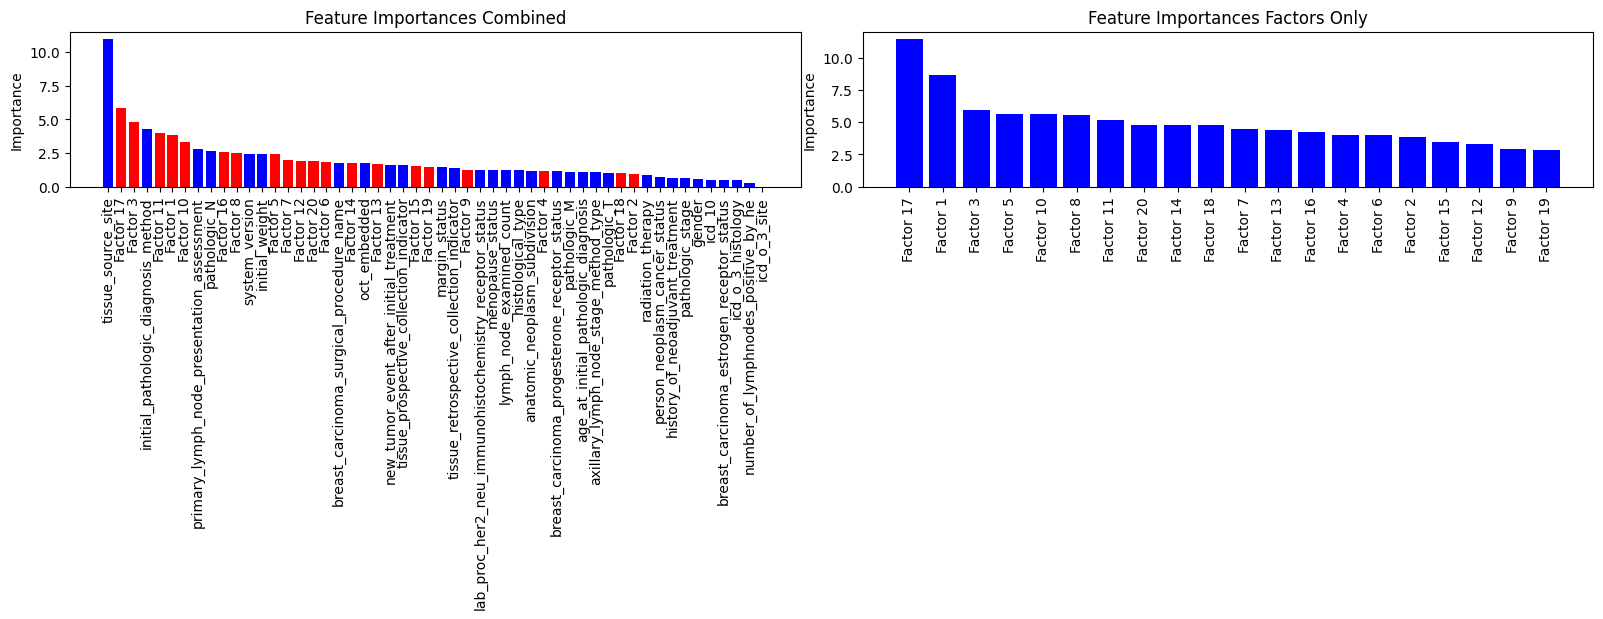

In [ ]:
# Строим регрессионную модель для факторов, полученных с использованием MOFA
mofa_metrics = regression_pipeline(mofa_factors, *pipeline_args)
m_f_mofa, m_c_mofa, c_f_mofa, c_c_mofa = mofa_metrics.values()

Мультиомиксные данные показаны красным.  
Левая картинка - важность признаков для датасета данных после мультиомиксной интеграции + клинические данные. Factor с номерами это инегрированные мультиомиксные данные, а строки с длинными названиями это клинические данные. Можно увидеть что импортенс первого признака (клинического) самый высокий, затем плавно падает. Среди топа фичей много тех, которые полученых с помощью мультиомиксной интеграции, но и клинические данные важны, оказывают влияние значимое.

PCA

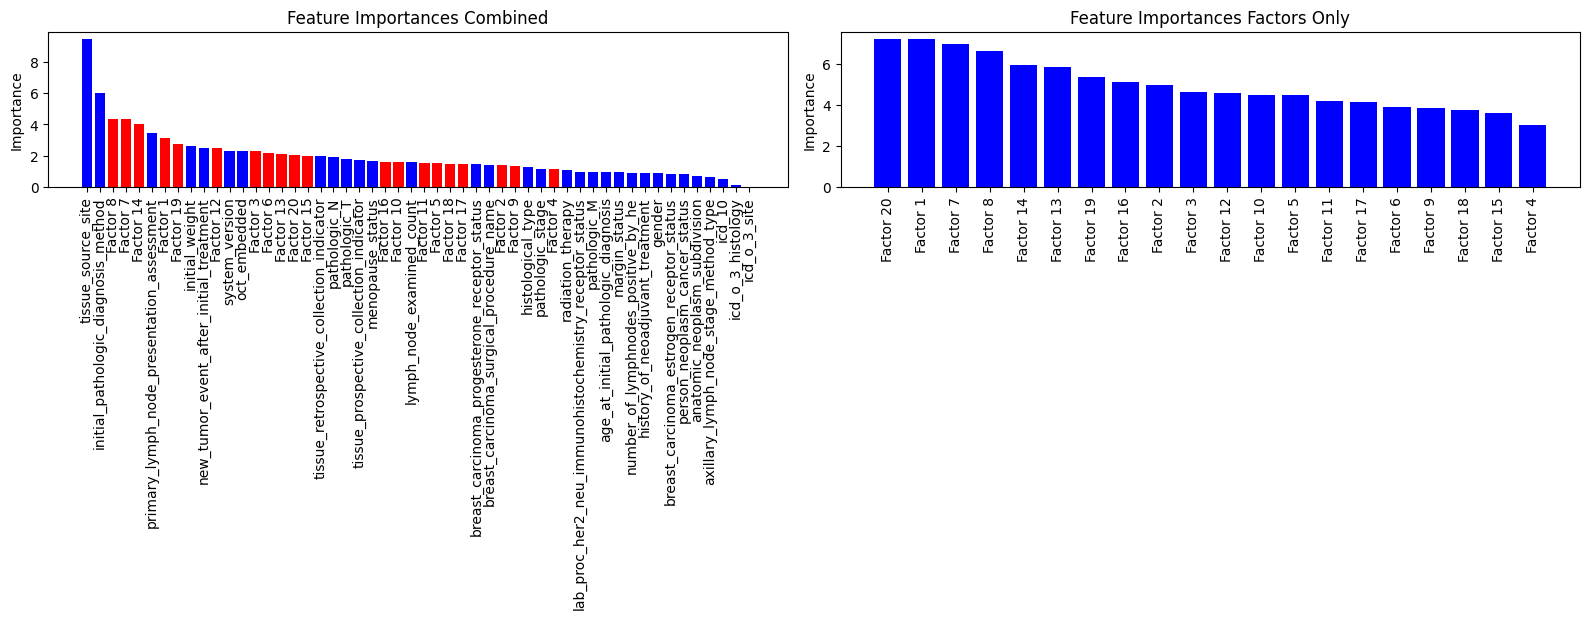

In [ ]:
# Строим регрессионную модель для факторов, полученных с использованием PCA
pca_metrics = regression_pipeline(pca_factors, *pipeline_args)

m_f_pca, m_c_pca, c_f_pca, c_c_pca = pca_metrics.values()

Похож на MOFA. Здесь два самых важных признака из клинических данных, но в том 10 фичей достаточно много вошли данных полученных с помощью мультиомиксной интеграции. Т.е. нельзя сказать что основыне признаки это только клинические данные. Значит мультиомиксная интеграция вносит результат какой то важный.  
Мультиомиксные данные в основном в левой части находятся - они одни из самых важных

Автоэнкодер

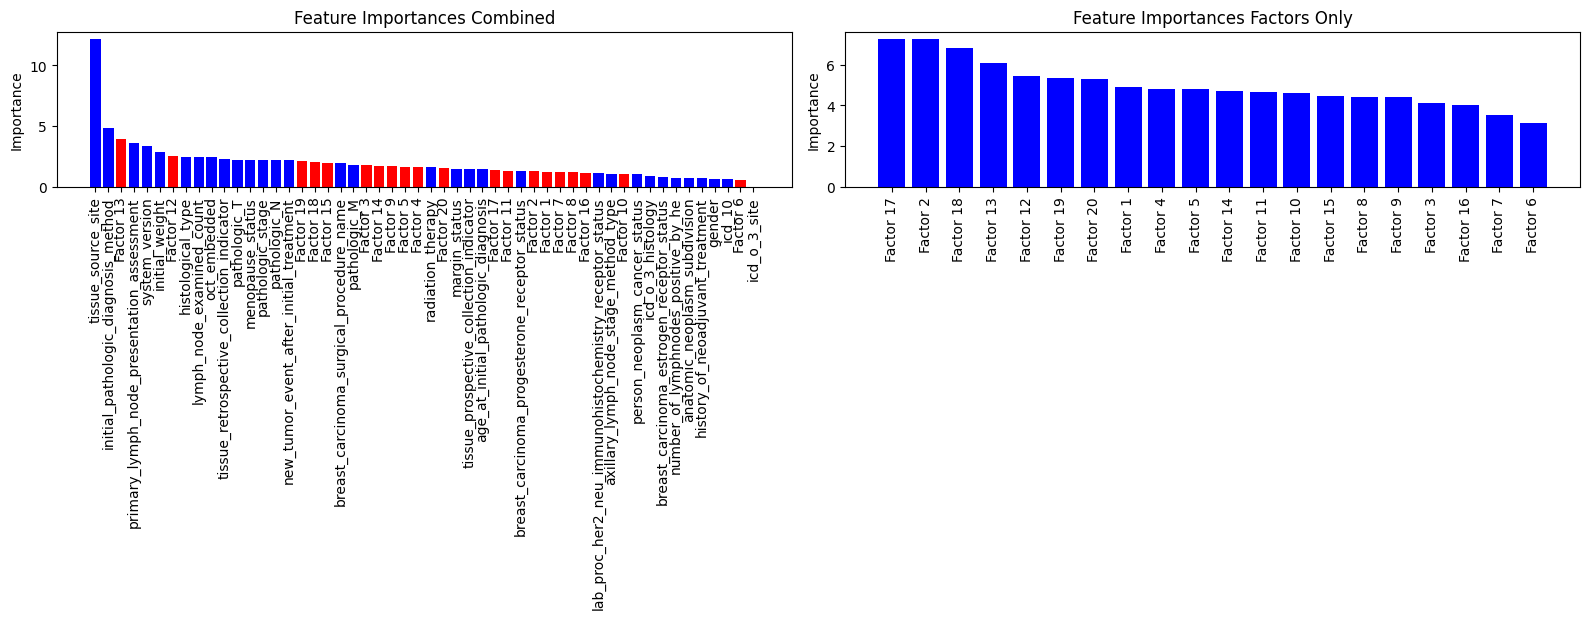

In [ ]:
# Строим регрессионную модель для факторов, полученных с использованием автоэнкодера
auto_metrics = regression_pipeline(autoenc_factors, *pipeline_args)

m_f_auto, m_c_auto, c_f_auto, c_c_auto = auto_metrics.values()

Автоэнкодер обходит классические модели вообще. У нас тут вышла картинка хуже. А также данных связанных с мультомиксной интеграцией в левой части намного меньше - это не хорошо, автоэнкодер не смог дать хорошие фичи. Скорее из за того, что он достаточно простой

## Сравнение метрик

Построим суммарную таблицу (используя метрики MAPE и c-index):  

MAPE - суммарная ошибка, выраженная в процентах, чем она больше тем хуже  
С-index - от 0.5 - случайный до 1 - идельаный классификатор.

In [ ]:
regr_results = pd.DataFrame({
    'MAPE factors, %': [m_f_pca,  m_f_mofa,  m_f_auto],
    'MAPE factors + clinical, %': [m_c_pca, m_c_mofa, m_c_auto],
    'C-index censored, factors': [c_f_pca, c_f_mofa, c_f_auto],
    'C-index censored, factors + clinical': [c_c_pca, c_c_mofa, c_c_auto]
}, index=['PCA', 'MOFA', 'Autoencoder'])

column_means = regr_results.iloc[:, :-1].mean(axis=0)
regr_results.to_csv('data/regression-res.csv')

regr_results

,"MAPE factors, %","MAPE factors + clinical, %","C-index censored, factors","C-index censored, factors + clinical"
PCA,131.770717,122.988408,0.632215,0.582550
MOFA,122.362252,116.114488,0.671141,0.604698
Autoencoder,143.649125,125.205852,0.566443,0.598658


Ошибка достаточно большая у автоэнкодера что и с клиническими данными, что без них. Но у PCA еще больше, он дал не плохой результат. У MOFA наименьшая.  
По с-index все классификаторы у нас не очень хорошие.  
Автоэнкодер дает не самый лучший результат и это может быть связано:
- у нас очень мало данных
- чтобы улучшить можно усложнить архитектуру (будем делать это ниже, сделаем его более многослойным), но не факт что это даст результат
- также можно данные не объединять а давать как отдельные модальности.

## Теперь будет пробовать вносить изменения

Запустим MOFA c параметром convergence_mode = «fast»:

In [ ]:
#функция для запуска интеграции мультиомиксных данных с использованием MOFA
def train_mofa(data_df, random_state=42, factors=10, train_params={'iter': 5000, 'convergence_mode': 'fast'}):
    ent = entry_point()
    # Устанавливаем опции для подготовки данных
    # - scale_views: приводить ли разные модальности в одинаковый диапазон по дисперсии. Мы не будем этого делать поэтому false
    ent.set_data_options(
        scale_views=False
    )

    # В качестве входных данных используем data frame
    ent.set_data_df(data_df)

    # устанавливаем параметры модели(параметр factors по умолчанию:10; ard_Factors - использовать оценки параметра sparsity общую для групп)
    ent.set_model_options(
        factors=factors,
        ard_factors=True
    )

    ## установливаем параметры обучения ##
    # - iter: число итераций
    # - convergence_mode: "fast", "medium", "slow". Чем медленее тем точнее происходит оптимизация. - режим конвергенции,
    # - dropR2: минимальное значени объясняемой дисперсии для того чтобы оставить фактор во время обучения. По умолчанию None.
    # - gpu_mode: Использовать GPU или нет
    # - seed: random seed

    ent.set_train_options(
        **train_params,
        gpu_mode=False,
        seed=random_state,
        quiet=True
    )

    ####################################
    ## Строим и обучаем MOFA модель ##
    ####################################

    # Строим модель
    ent.build()

    # Запускем обучение модели
    ent.run()

    ####################
    ## Сохраняем модель ##
    ####################

    outfile = f"data/outputs/test_{time.time()}.hdf5"

    # - save_data: сохранять ли данные обучения в hdf5 файле.
    ent.save(outfile, save_data=True)

    #########################
    ## Downstream analysis ##
    #########################

    #

    # Извлекаем значение факторов
    factors = ent.model.nodes["Z"].getExpectation()

    # Извлекаем веса
    weights = ent.model.nodes["W"].getExpectation()

    # Извлекаем значения объясняемой дисперсии
    r2 = ent.model.calculate_variance_explained()

    return factors, weights, r2

In [ ]:
#запускаем MOFA
RANDOM_STATE = 42
N_FACTORS = 20 # число факторов
mofa_factors, weights, r2 = train_mofa(mofa_data_breast.copy(), RANDOM_STATE, factors=N_FACTORS)
clear_output()

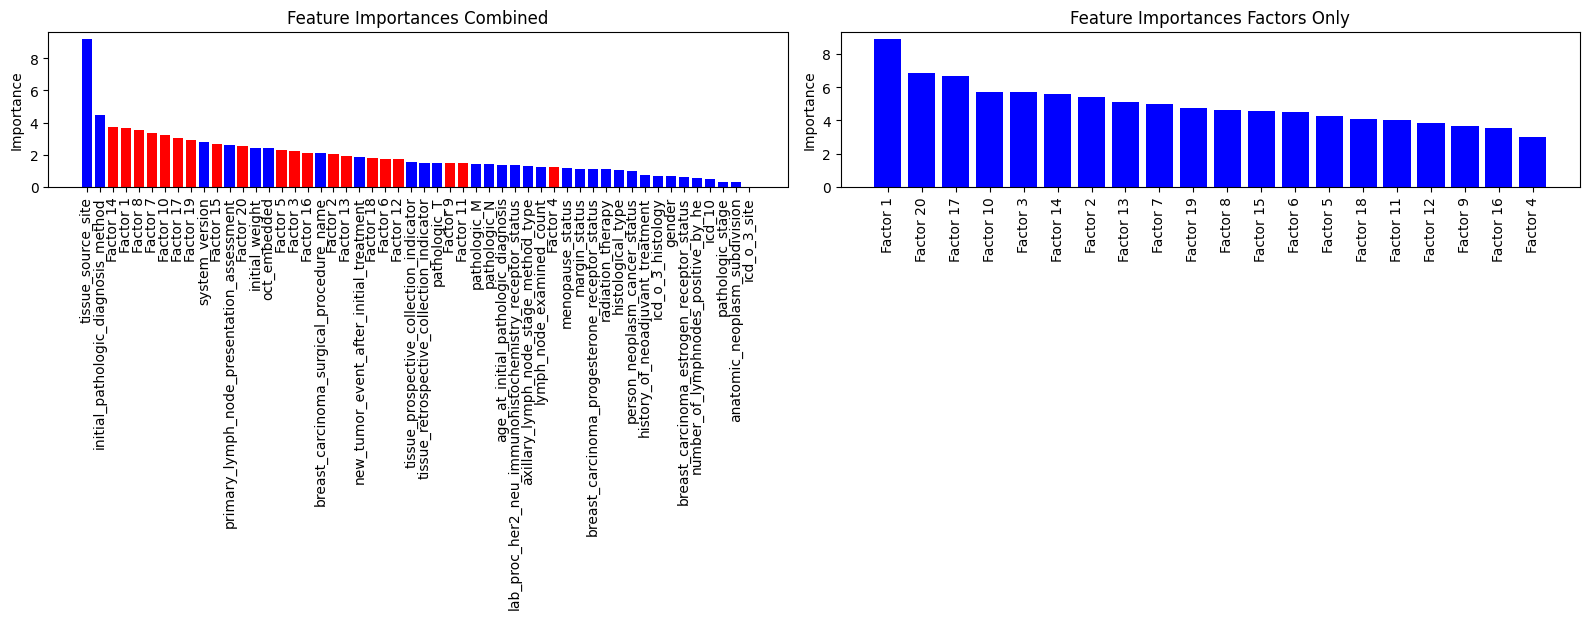

In [ ]:
# Строим регрессионную модель для факторов, полученных с использованием MOFA
mofa_metrics = regression_pipeline(mofa_factors, *pipeline_args)
m_f_mofa, m_c_mofa, c_f_mofa, c_c_mofa = mofa_metrics.values()

In [ ]:
regr_results = pd.DataFrame({
    'MAPE factors, %': [m_f_mofa],
    'MAPE factors + clinical, %': [m_c_mofa],
    'C-index censored, factors': [c_f_mofa],
    'C-index censored, factors + clinical': [c_c_mofa]
}, index=['MOFA'])

column_means = regr_results.iloc[:, :-1].mean(axis=0)
#regr_results.to_csv('data/regression-res.csv')

regr_results

,"MAPE factors, %","MAPE factors + clinical, %","C-index censored, factors","C-index censored, factors + clinical"
MOFA,125.928212,116.476813,0.622148,0.622819


Видим что качество метрики c-index ухудшилось при быстром режиме конвергенции, да и MAPE увеличилась без клинических данных - что говорит о том, что чем медленнее, тем точнее получается модель.

Попробуем эмпирически подобрать оптимальное количество эпох для обучения автоэнкодера.  
Оптимальное количество в смысле получения максимально возможного качества регресионной модели(параметры MAPE и C-index)

Автоэнкодер  

Попробуем для 100 эпох

In [ ]:
#Задаём автоэнкодер
class Autoencoder(nn.Module):
    def __init__(self, input_dims, n_out):
        super(Autoencoder, self).__init__()
        hidden_dim = sum([d for d in input_dims])
        # кодирующий слой, на входе общее число признаков в трёх модальностях на выходе 128 признаков
        self.encoder = nn.Sequential(
            nn.Linear(hidden_dim, 128), # на входе энкодера hidden_dim(общее число признаков во всех модальностях) признаков, на выходе 128
            nn.Tanh(), # функция активации tanh
            nn.Dropout(0.5) # применяем dropout с вероятностью 0.5
        )
        # скрытый слой из 128 узлов
        self.bottleneck = nn.Linear(128, n_out) # на входе 128 признаков, на выходе столько сколько факторов задано

        # декодирующий слой
        self.decoder = nn.Sequential(
            nn.Linear(n_out, hidden_dim), # на входе количество признаков равное числу факторов на выходе общее число признаков во всех модальностях
            nn.Sigmoid() # функция активации
        )

    def forward(self, inputs): # прямой проход через сеть
        inputs = torch.cat(inputs, dim=1) # объединяем данные в одну матрицу
        encoded = self.encoder(inputs) # прогоняем через кодирующий слой
        bottleneck = self.bottleneck(encoded) # прогоняем через скрытый слой
        # bottleneck - содержит искомые факторы
        decoded = self.decoder(bottleneck) # прогоняем через декодер
        return decoded # на выходе реконструированные признаки после декодирующего слоя

    def encode(self, inputs): # прогоняем данные через кодирующий слой и скрытый внутренний слой
        inputs = torch.cat(inputs, dim=1) # объединяем данные в одну матрицу
        encoded = self.encoder(inputs) # прогоняем через кодирующий слой
        bottleneck = self.bottleneck(encoded) # прогоняем через скрытый слой
        return bottleneck # на выходе признаки, полученные после кодирования и сжатия в скрытом слое. Это и есть факторы.



class EncoderPipeline(): # Основной класс создающий и обучающий автоэнкодер
    def __init__(self, modalities, n_out, random_state, base=False):
        self.modalities = modalities
        self.random_state = random_state
        self.input_dims = [mod.shape[1] for mod in self.modalities]
        self.model = Autoencoder(self.input_dims, n_out) # создаём автоэнкодер self.input_dims входных признаков n_out - число признаков после внутреннего скрытого слоя автоэнкодера перед декодером
        # это и есть наши эмбеддинги
        self.device = torch.device("cpu") # всё это делаем на CPU
        self.train_loader = self.create_loader(self.modalities) # преобразуем данные в формат pytorch Tensor

    def create_loader(self, modalities):
        dna_train, rna_train, methylation_train = [
            torch.tensor(mod, dtype=torch.float32) for mod in modalities
        ]
        train_dataset = TensorDataset(dna_train, rna_train, methylation_train)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
        self.train_dataset = Dataset.from_dict({
            "inputs": train_dataset.tensors,
        })
        return train_loader

    def fit(self): # обучаем модель
        random.seed(self.random_state)
        np.random.seed(self.random_state)
        torch.manual_seed(self.random_state)
        torch.cuda.manual_seed_all(self.random_state)

        self.model.to(self.device)

         # Создаём оптимизатор и функцию потерь
        optimizer = optim.AdamW(self.model.parameters(), lr=0.001)
        criterion = nn.MSELoss()

        # Обучение
        for epoch in range(100): # используем 100 эпох
            self.model.train() #инициализация
            running_loss = 0.0
            for data in self.train_loader:
                inputs = [modality.to(self.device) for modality in data]
                targets = torch.cat(inputs, dim=1)

                optimizer.zero_grad()
                outputs = self.model(inputs)
                # значение функции потерь
                loss = sum(criterion(output, target)
                           for output, target in zip(outputs, targets))
                # считаем градиент
                loss.backward()
                # обновляем веса
                optimizer.step()

                running_loss += loss.item()

            print(f"Epoch {epoch+1}, Loss: {running_loss}")

    def transform(self, modalities=None): # подсчёт факторов для данных
        self.model.to(self.device)
        self.model.eval()
        output = []
        with torch.no_grad():
            to_transform = self.train_loader if not modalities else self.create_loader(modalities)
            for data in to_transform:
                inputs = [modality.to(self.device) for modality in data]
                outputs = self.model.encode(inputs)
                output.append(outputs.cpu())
        output = np.vstack(output)
        return output

In [ ]:
torch.set_num_threads(1)

# создаём автоэнкодер
enc_pipeline = EncoderPipeline([expression_data_breast.values, mirna_data_breast.values, methylation_data_breast.values], N_FACTORS, RANDOM_STATE, base=False)
# обучаем автоэнкодер
enc_pipeline.fit()

clear_output()
#считаем эмбеддинги
autoenc_factors = enc_pipeline.transform()

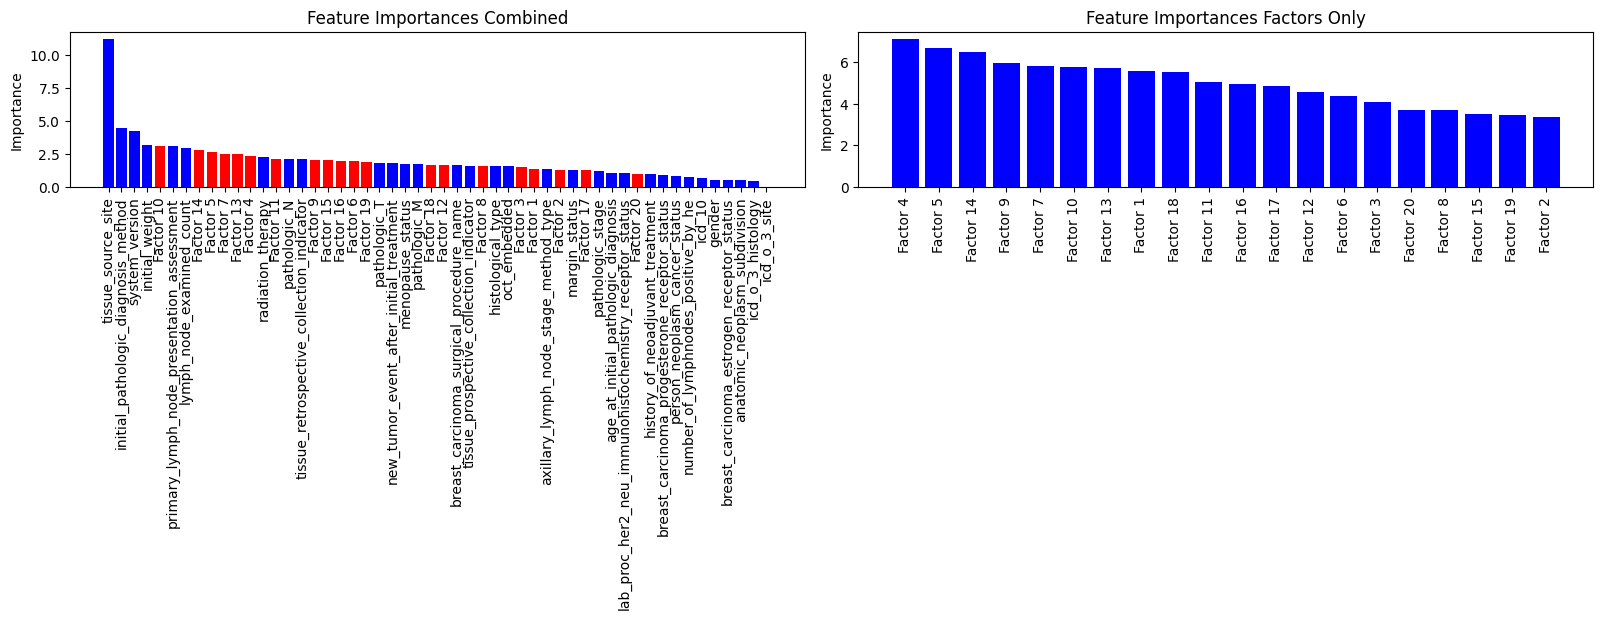

In [ ]:
# Строим регрессионную модель для факторов, полученных с использованием автоэнкодера
auto_metrics = regression_pipeline(autoenc_factors, *pipeline_args)

m_f_auto, m_c_auto, c_f_auto, c_c_auto = auto_metrics.values()

In [ ]:
regr_results = pd.DataFrame({
    'MAPE factors, %': [m_f_auto],
    'MAPE factors + clinical, %': [m_c_auto],
    'C-index censored, factors': [c_f_auto],
    'C-index censored, factors + clinical': [c_c_auto]
}, index=['Autoencoder'])

column_means = regr_results.iloc[:, :-1].mean(axis=0)
#regr_results.to_csv('data/regression-res.csv')

regr_results

,"MAPE factors, %","MAPE factors + clinical, %","C-index censored, factors","C-index censored, factors + clinical"
Autoencoder,151.171999,123.393793,0.537584,0.585235


И попробуем для 1000 эпох:

In [ ]:
#Задаём автоэнкодер
class Autoencoder(nn.Module):
    def __init__(self, input_dims, n_out):
        super(Autoencoder, self).__init__()
        hidden_dim = sum([d for d in input_dims])
        # кодирующий слой, на входе общее число признаков в трёх модальностях на выходе 128 признаков
        self.encoder = nn.Sequential(
            nn.Linear(hidden_dim, 128), # на входе энкодера hidden_dim(общее число признаков во всех модальностях) признаков, на выходе 128
            nn.Tanh(), # функция активации tanh
            nn.Dropout(0.5) # применяем dropout с вероятностью 0.5
        )
        # скрытый слой из 128 узлов
        self.bottleneck = nn.Linear(128, n_out) # на входе 128 признаков, на выходе столько сколько факторов задано

        # декодирующий слой
        self.decoder = nn.Sequential(
            nn.Linear(n_out, hidden_dim), # на входе количество признаков равное числу факторов на выходе общее число признаков во всех модальностях
            nn.Sigmoid() # функция активации
        )

    def forward(self, inputs): # прямой проход через сеть
        inputs = torch.cat(inputs, dim=1) # объединяем данные в одну матрицу
        encoded = self.encoder(inputs) # прогоняем через кодирующий слой
        bottleneck = self.bottleneck(encoded) # прогоняем через скрытый слой
        # bottleneck - содержит искомые факторы
        decoded = self.decoder(bottleneck) # прогоняем через декодер
        return decoded # на выходе реконструированные признаки после декодирующего слоя

    def encode(self, inputs): # прогоняем данные через кодирующий слой и скрытый внутренний слой
        inputs = torch.cat(inputs, dim=1) # объединяем данные в одну матрицу
        encoded = self.encoder(inputs) # прогоняем через кодирующий слой
        bottleneck = self.bottleneck(encoded) # прогоняем через скрытый слой
        return bottleneck # на выходе признаки, полученные после кодирования и сжатия в скрытом слое. Это и есть факторы.



class EncoderPipeline(): # Основной класс создающий и обучающий автоэнкодер
    def __init__(self, modalities, n_out, random_state, base=False):
        self.modalities = modalities
        self.random_state = random_state
        self.input_dims = [mod.shape[1] for mod in self.modalities]
        self.model = Autoencoder(self.input_dims, n_out) # создаём автоэнкодер self.input_dims входных признаков n_out - число признаков после внутреннего скрытого слоя автоэнкодера перед декодером
        # это и есть наши эмбеддинги
        self.device = torch.device("cpu") # всё это делаем на CPU
        self.train_loader = self.create_loader(self.modalities) # преобразуем данные в формат pytorch Tensor

    def create_loader(self, modalities):
        dna_train, rna_train, methylation_train = [
            torch.tensor(mod, dtype=torch.float32) for mod in modalities
        ]
        train_dataset = TensorDataset(dna_train, rna_train, methylation_train)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
        self.train_dataset = Dataset.from_dict({
            "inputs": train_dataset.tensors,
        })
        return train_loader

    def fit(self): # обучаем модель
        random.seed(self.random_state)
        np.random.seed(self.random_state)
        torch.manual_seed(self.random_state)
        torch.cuda.manual_seed_all(self.random_state)

        self.model.to(self.device)

         # Создаём оптимизатор и функцию потерь
        optimizer = optim.AdamW(self.model.parameters(), lr=0.001)
        criterion = nn.MSELoss()

        # Обучение
        for epoch in range(1000): # используем 1000 эпох
            self.model.train() #инициализация
            running_loss = 0.0
            for data in self.train_loader:
                inputs = [modality.to(self.device) for modality in data]
                targets = torch.cat(inputs, dim=1)

                optimizer.zero_grad()
                outputs = self.model(inputs)
                # значение функции потерь
                loss = sum(criterion(output, target)
                           for output, target in zip(outputs, targets))
                # считаем градиент
                loss.backward()
                # обновляем веса
                optimizer.step()

                running_loss += loss.item()

            print(f"Epoch {epoch+1}, Loss: {running_loss}")

    def transform(self, modalities=None): # подсчёт факторов для данных
        self.model.to(self.device)
        self.model.eval()
        output = []
        with torch.no_grad():
            to_transform = self.train_loader if not modalities else self.create_loader(modalities)
            for data in to_transform:
                inputs = [modality.to(self.device) for modality in data]
                outputs = self.model.encode(inputs)
                output.append(outputs.cpu())
        output = np.vstack(output)
        return output

In [ ]:
torch.set_num_threads(1)

# создаём автоэнкодер
enc_pipeline = EncoderPipeline([expression_data_breast.values, mirna_data_breast.values, methylation_data_breast.values], N_FACTORS, RANDOM_STATE, base=False)
# обучаем автоэнкодер
enc_pipeline.fit()

clear_output()
#считаем эмбеддинги
autoenc_factors = enc_pipeline.transform()

Loss перестал уменьшаться  после 250 эпохи в общем

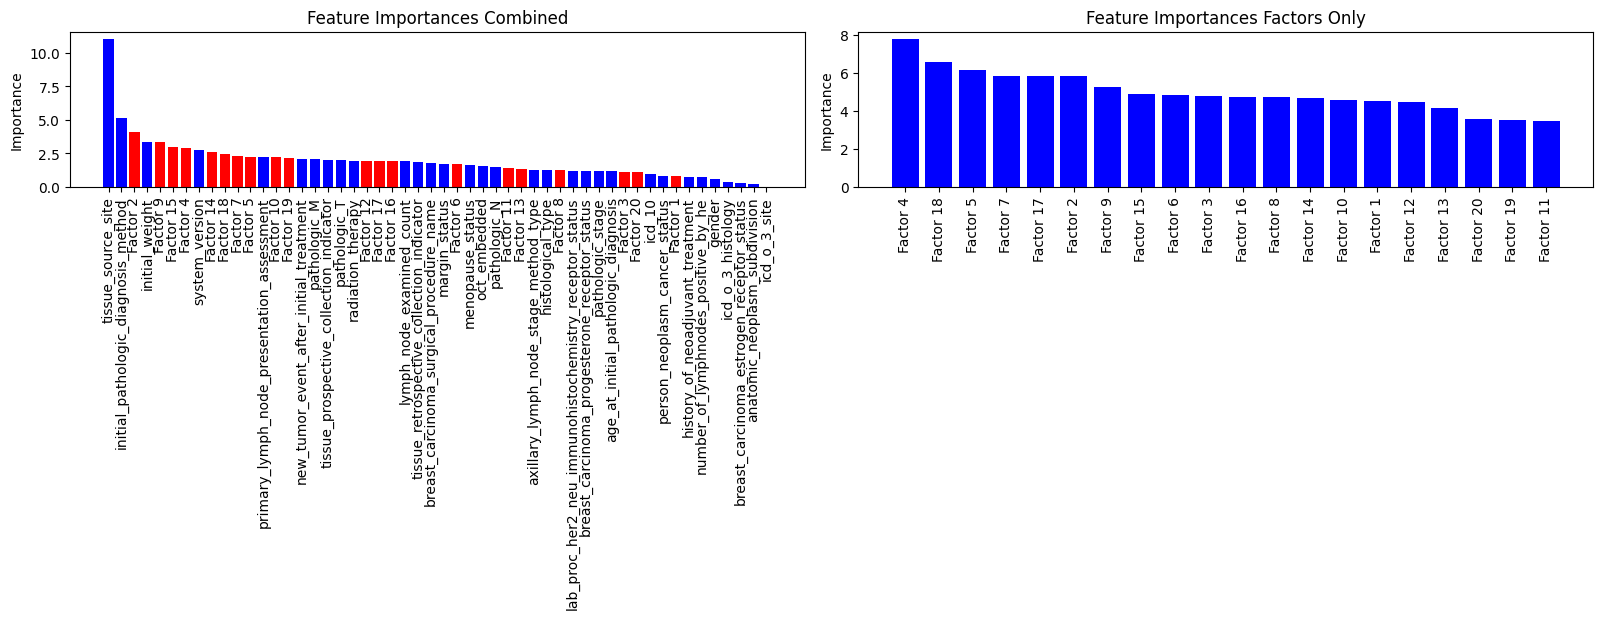

In [ ]:
# Строим регрессионную модель для факторов, полученных с использованием автоэнкодера
auto_metrics = regression_pipeline(autoenc_factors, *pipeline_args)

m_f_auto, m_c_auto, c_f_auto, c_c_auto = auto_metrics.values()

In [ ]:
regr_results = pd.DataFrame({
    'MAPE factors, %': [m_f_auto],
    'MAPE factors + clinical, %': [m_c_auto],
    'C-index censored, factors': [c_f_auto],
    'C-index censored, factors + clinical': [c_c_auto]
}, index=['Autoencoder'])

column_means = regr_results.iloc[:, :-1].mean(axis=0)
#regr_results.to_csv('data/regression-res.csv')

regr_results

,"MAPE factors, %","MAPE factors + clinical, %","C-index censored, factors","C-index censored, factors + clinical"
Autoencoder,141.342796,128.509654,0.541611,0.586577


MAPE c клиническими данными увеличисля, что не очень, а вот без них наоборот уменьшился. Также немного увеличился c-index, что хорошо.

 Попробуем изменить архитектуру автоэнкодера на приведённую ниже:

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dims, n_out):
        super(Autoencoder, self).__init__()
        dna_encoder = nn.Sequential(
        # кодирующий слой, на входе общее число признаков в трёх модальностях на выходе 128 признаков
            nn.Linear(input_dims[0], 128), # ОПИСАТЬ ТУТ
            nn.BatchNorm1d(128),
            nn.ReLU(), # функция активации relu
            nn.Dropout(0.3) # применяем dropout с вероятностью 0.3
        )
        # скрытый слой из 128 узлов
        rna_encoder = nn.Sequential(
            nn.Linear(input_dims[1], 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        met_encoder = nn.Sequential(
            nn.Linear(input_dims[2], 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.encoder = nn.ModuleList([dna_encoder, rna_encoder, met_encoder])
        self.bottleneck = nn.Linear(128 * len(input_dims), n_out)
        self.decoder = nn.ModuleList([nn.Sequential(
            nn.Linear(n_out, dim),
            nn.Sigmoid()
        ) for dim in input_dims])


    def forward(self, inputs):
        encoded = [encoder(input)
                   for encoder, input in zip(self.encoder, inputs)]
        merged = torch.cat(encoded, dim=1)
        bottleneck = self.bottleneck(merged)
        decoded = [decoder(bottleneck) for decoder in self.decoder]
        return decoded

    def encode(self, inputs):
        encoded = [encoder(input)
                   for encoder, input in zip(self.encoder, inputs)]
        merged = torch.cat(encoded, dim=1)
        bottleneck = self.bottleneck(merged)
        return bottleneck

class EncoderPipeline(): # Основной класс создающий и обучающий автоэнкодер
    def __init__(self, modalities, n_out, random_state, base=False):
        self.modalities = modalities
        self.random_state = random_state
        self.input_dims = [mod.shape[1] for mod in self.modalities]
        self.model = Autoencoder(self.input_dims, n_out) # создаём автоэнкодер self.input_dims входных признаков n_out - число признаков после внутреннего скрытого слоя автоэнкодера перед декодером
        # это и есть наши эмбеддинги
        self.device = torch.device("cpu") # всё это делаем на CPU
        self.train_loader = self.create_loader(self.modalities) # преобразуем данные в формат pytorch Tensor

    def create_loader(self, modalities):
        dna_train, rna_train, methylation_train = [
            torch.tensor(mod, dtype=torch.float32) for mod in modalities
        ]
        train_dataset = TensorDataset(dna_train, rna_train, methylation_train)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
        self.train_dataset = Dataset.from_dict({
            "inputs": train_dataset.tensors,
        })
        return train_loader

    def fit(self): # обучаем модель
        random.seed(self.random_state)
        np.random.seed(self.random_state)
        torch.manual_seed(self.random_state)
        torch.cuda.manual_seed_all(self.random_state)

        self.model.to(self.device)

         # Создаём оптимизатор и функцию потерь
        optimizer = optim.AdamW(self.model.parameters(), lr=0.001)
        criterion = nn.MSELoss()

        # Обучение
        for epoch in range(50): # используем 50 эпох
            self.model.train() #инициализация
            running_loss = 0.0
            for data in self.train_loader:
                inputs = [modality.to(self.device) for modality in data]
                #targets = torch.cat(inputs, dim=1)
                targets = inputs

                optimizer.zero_grad()
                outputs = self.model(inputs)
                # значение функции потерь
                loss = sum(criterion(output, target)
                           for output, target in zip(outputs, targets))
                # считаем градиент
                loss.backward()
                # обновляем веса
                optimizer.step()

                running_loss += loss.item()

            print(f"Epoch {epoch+1}, Loss: {running_loss}")

    def transform(self, modalities=None): # подсчёт факторов для данных
        self.model.to(self.device)
        self.model.eval()
        output = []
        with torch.no_grad():
            to_transform = self.train_loader if not modalities else self.create_loader(modalities)
            for data in to_transform:
                inputs = [modality.to(self.device) for modality in data]
                outputs = self.model.encode(inputs)
                output.append(outputs.cpu())
        output = np.vstack(output)
        return output

In [ ]:
torch.set_num_threads(1)

# создаём автоэнкодер
enc_pipeline = EncoderPipeline([expression_data_breast.values, mirna_data_breast.values, methylation_data_breast.values], N_FACTORS, RANDOM_STATE, base=False)
# обучаем автоэнкодер
enc_pipeline.fit()

clear_output()
#считаем эмбеддинги
autoenc_factors = enc_pipeline.transform()

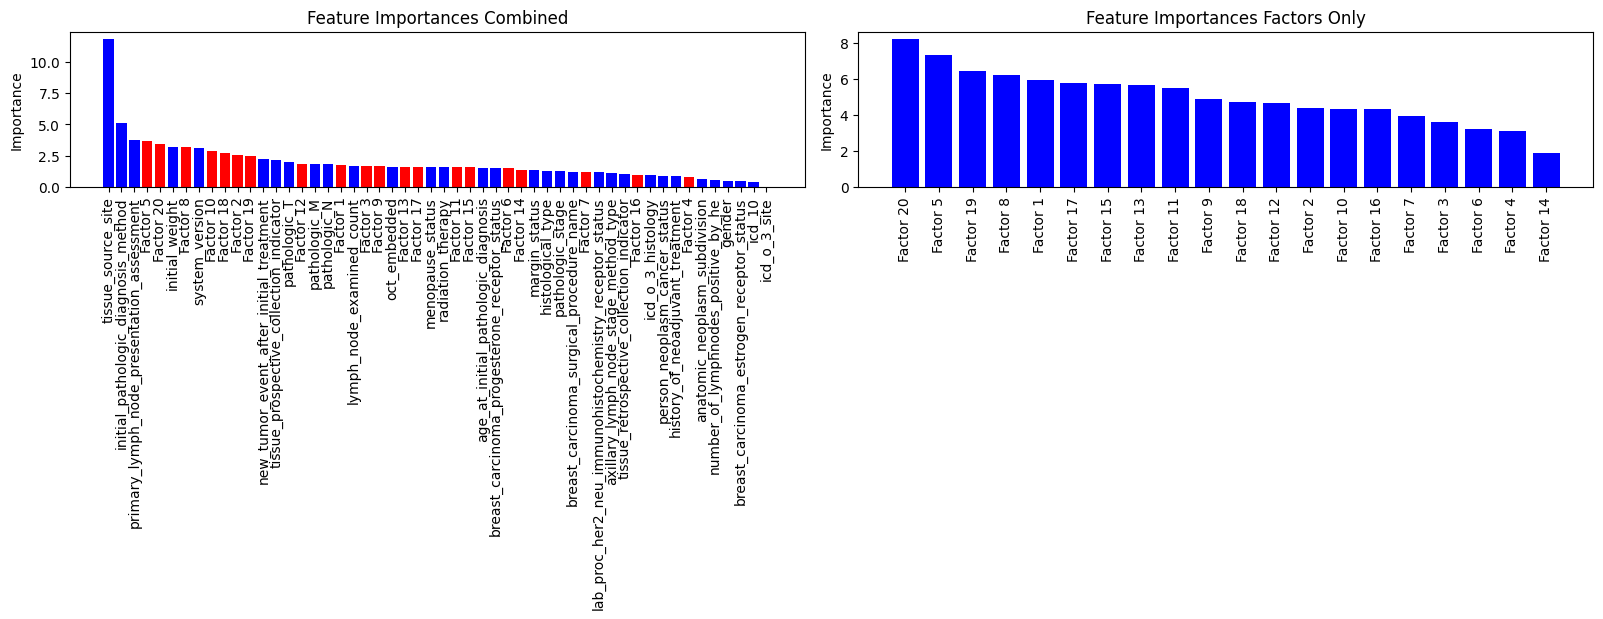

In [ ]:
# Строим регрессионную модель для факторов, полученных с использованием автоэнкодера
auto_metrics = regression_pipeline(autoenc_factors, *pipeline_args)

m_f_auto, m_c_auto, c_f_auto, c_c_auto = auto_metrics.values()

In [ ]:
regr_results = pd.DataFrame({
    'MAPE factors, %': [m_f_auto],
    'MAPE factors + clinical, %': [m_c_auto],
    'C-index censored, factors': [c_f_auto],
    'C-index censored, factors + clinical': [c_c_auto]
}, index=['Autoencoder'])

column_means = regr_results.iloc[:, :-1].mean(axis=0)
#regr_results.to_csv('data/regression-res.csv')

regr_results

,"MAPE factors, %","MAPE factors + clinical, %","C-index censored, factors","C-index censored, factors + clinical"
Autoencoder,137.577443,121.323707,0.554362,0.583893


##UMAP

In [ ]:
os.system("pip install umap-learn")

import umap

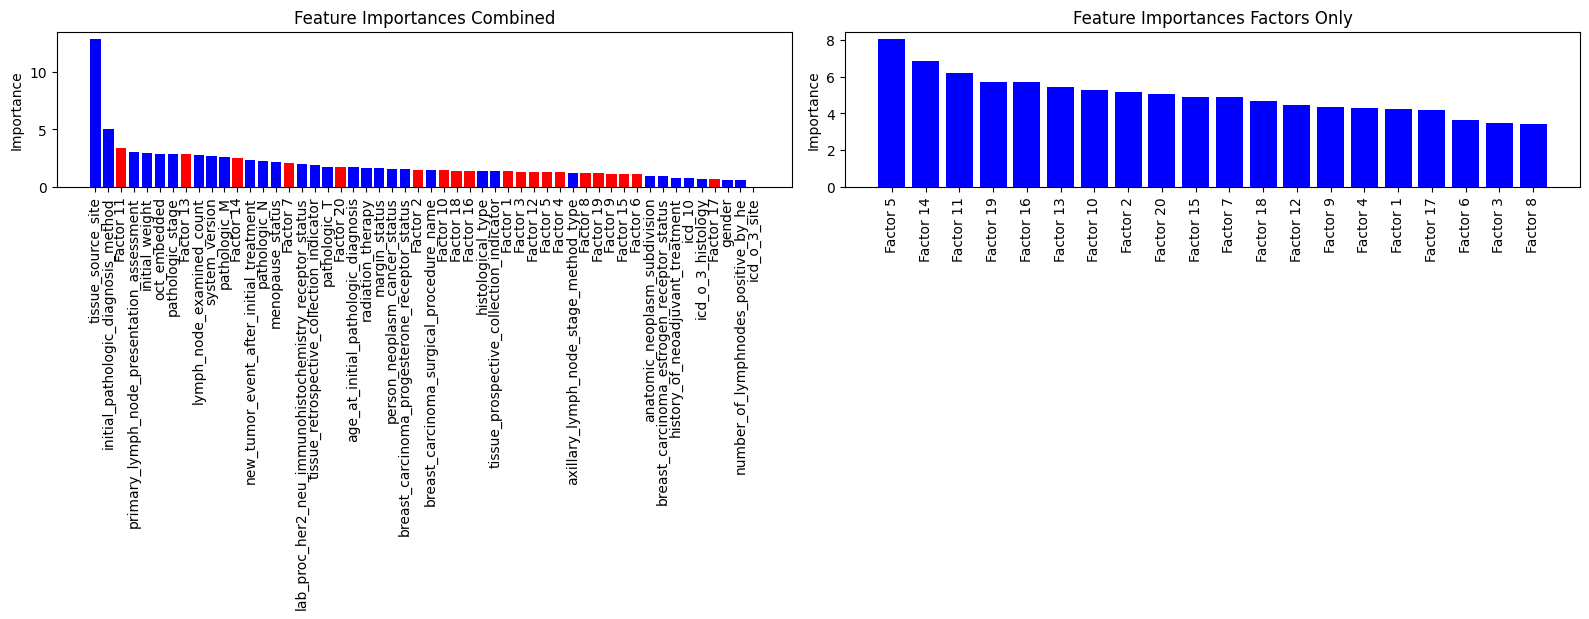

In [ ]:
reducer = umap.UMAP(n_components=N_FACTORS, random_state=RANDOM_STATE)

umap_factors = reducer.fit_transform(X_breast_all)

umap_metrics = regression_pipeline(umap_factors, *pipeline_args)

m_f_umap, m_c_umap, c_f_umap, c_c_umap = umap_metrics.values()

Тут наоборот видим, что данные связанные м мультиомиксной интеграцией в правой больше, чем в левой, они практически в топ 10 фичей не входят.

In [ ]:
regr_results = pd.DataFrame({
    'MAPE factors, %': [m_f_umap],
    'MAPE factors + clinical, %': [m_c_umap],
    'C-index censored, factors': [c_f_umap],
    'C-index censored, factors + clinical': [c_c_umap]
}, index=['UMAP'])

column_means = regr_results.iloc[:, :-1].mean(axis=0)
#regr_results.to_csv('data/regression-res.csv')

regr_results

,"MAPE factors, %","MAPE factors + clinical, %","C-index censored, factors","C-index censored, factors + clinical"
UMAP,136.763139,124.894264,0.665101,0.588591


Видим что c-index лучше чем у автоэнкодера, а по MAPE все же уступает PCA.